In [1]:
!pip install torchinfo
!pip install torch

In [2]:
import os
import sys
from collections import Counter

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import PIL
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from torch.utils.data import DataLoader, random_split
from torchinfo import summary
from torchvision import datasets, transforms
from tqdm.notebook import tqdm
import zipfile

In [3]:
print("Platform:", sys.platform)
print("Python version:", sys.version)
print("---")
print("pandas version:", pd.__version__)
print("PIL version:", PIL.__version__)
print("torch version:", torch.__version__)
print("torchvision version:", torchvision.__version__)

Platform: linux
Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
---
pandas version: 2.2.2
PIL version: 11.3.0
torch version: 2.11.0+cpu
torchvision version: 0.26.0+cpu


In [4]:
zip_path = "/content/drive/MyDrive/sea_creatures.zip"

extraction_path = "/content/dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extraction_path)

print("Image Dataset extracted successfully")

Image Dataset extracted successfully


Th Dataset cointains raw images some of them being RGB,grayscale and of different sizes.

Data Mismatch Causes errors in a DataLoader



## Step 1: Transformation Pipeline (Phase 1)

In [5]:
# This OOP Code when called its takes our mage data as an instance and convert the objects into RGB
class ConvertToRGB:
    def __call__(self, img):
        if img.mode != "RGB":
            img = img.convert("RGB")
        return img

In [7]:
transform = transforms.Compose([
    ConvertToRGB(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

### Stage:The Data is supposed to transformed

In [9]:
train_dir = os.path.join("dataset", "train")

classes = os.listdir(train_dir)

print(classes)

['Sea Urchins', 'Puffers', 'Turtle_Tortoise', 'Dolphin', 'Octopus', 'Jelly Fish', 'Whale', 'Sharks', 'Sea Rays']


In [10]:
# Transform the Data
dataset = datasets.ImageFolder(root=train_dir, transform=transform)

In [11]:
print("Tensor shape for one image:")
print(dataset[0][0].shape)

Tensor shape for one image:
torch.Size([3, 224, 224])


Unlike Standard ML where we transform data and then fit it to the model,image datasets are too large hence would crash the memory

Data is loaded in Batches processed and then another batch picked up

In [12]:
batch_size = 32

dataset_loader = DataLoader(dataset, batch_size=batch_size)

first_batch = next(iter(dataset_loader))

print(f"Shape of one batch: {first_batch[0].shape}")
print(f"Shape of labels: {first_batch[1].shape}")

Shape of one batch: torch.Size([32, 3, 224, 224])
Shape of labels: torch.Size([32])


# Preparing Our Data

Neural networks learn faster, more stably, and more accurately when the input features are centered around 0 and have a similar scale.

In [13]:
def get_mean_std(loader):
    """Computes the mean and standard deviation of image data.

    Input: a `DataLoader` producing tensors of shape [batch_size, channels, pixels_x, pixels_y]
    Output: the mean of each channel as a tensor, the standard deviation of each channel as a tensor
            formatted as a tuple (means[channels], std[channels])"""

    channels_sum, channels_squared_sum, num_batches = 0, 0, 0
    for data, _ in tqdm(loader, desc="Computing mean and std", leave=False):
        channels_sum += torch.mean(data, dim=[0, 2, 3])
        channels_squared_sum += torch.mean(data**2, dim=[0, 2, 3])
        num_batches += 1
    mean = channels_sum / num_batches
    std = (channels_squared_sum / num_batches - mean**2) ** 0.5

    return mean, std

In [14]:
mean, std = get_mean_std(dataset_loader)

print(f"Mean: {mean}")
print(f"Standard deviation: {std}")

Computing mean and std:   0%|          | 0/194 [00:00<?, ?it/s]

Mean: tensor([0.2992, 0.4125, 0.4588])
Standard deviation: tensor([0.2697, 0.2404, 0.2658])


In [15]:
transform_norm = transforms.Compose(
    [
        ConvertToRGB(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ]
)

In [16]:
norm_dataset = datasets.ImageFolder(root= train_dir, transform=transform_norm)

norm_loader = DataLoader(norm_dataset, batch_size=batch_size)

In [17]:
norm_mean, norm_std = get_mean_std(norm_loader)

print(f"Mean: {norm_mean}")
print(f"Standard deviation: {norm_std}")

Computing mean and std:   0%|          | 0/194 [00:00<?, ?it/s]

Mean: tensor([1.0254e-07, 4.2877e-07, 3.8482e-07])
Standard deviation: tensor([1.0000, 1.0000, 1.0000])


# Train and Validation Splitting

In [19]:
train_dataset, val_dataset = random_split(norm_dataset, [0.8, 0.2])

length_train = len(train_dataset)
length_val = len(val_dataset)
length_dataset = len(norm_dataset)
percent_train = np.round(100 * length_train / length_dataset, 2)
percent_val = np.round(100 * length_val / length_dataset, 2)

print(f"Train data is {percent_train}% of full data")
print(f"Validation data is {percent_val}% of full data")

Train data is 80.01% of full data
Validation data is 19.99% of full data


# Train & Test Distribution

In [20]:
def class_counts(dataset):
    c = Counter(x[1] for x in tqdm(dataset))
    class_to_index = dataset.dataset.class_to_idx
    return pd.Series({cat: c[idx] for cat, idx in class_to_index.items()})

In [21]:
train_class_distributions = class_counts(train_dataset)

train_class_distributions

  0%|          | 0/4946 [00:00<?, ?it/s]

,0
Dolphin,571
Jelly Fish,587
Octopus,407
Puffers,396
Sea Rays,357
Sea Urchins,423
Sharks,414
Turtle_Tortoise,1379
Whale,412


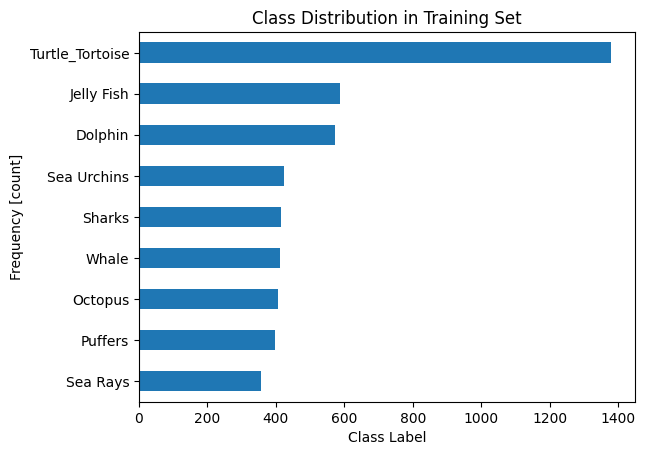

In [22]:
train_class_distributions.sort_values().plot(kind="barh")

plt.xlabel("Class Label")
plt.ylabel("Frequency [count]")
plt.title("Class Distribution in Training Set");

In [23]:
validation_class_distributions = class_counts(val_dataset)

print(validation_class_distributions)

  0%|          | 0/1236 [00:00<?, ?it/s]

Dolphin            140
Jelly Fish         165
Octopus             88
Puffers             92
Sea Rays            94
Sea Urchins        101
Sharks             119
Turtle_Tortoise    337
Whale              100
dtype: int64


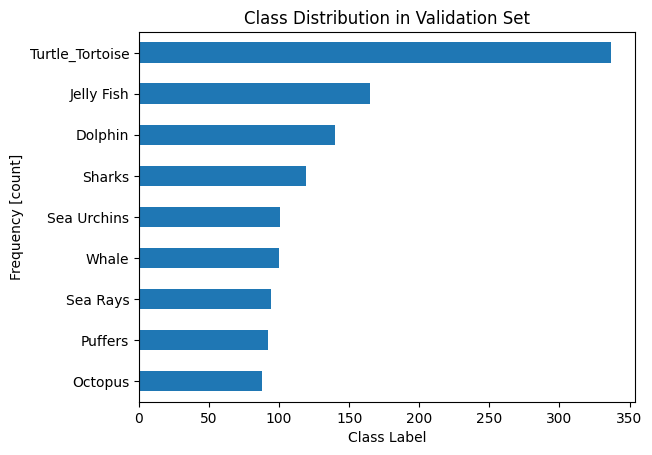

In [24]:
validation_class_distributions.sort_values().plot(kind="barh")


plt.xlabel("Class Label")
plt.ylabel("Frequency [count]")
plt.title("Class Distribution in Validation Set");

In [25]:
batch_size = 32

train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True)

val_loader = DataLoader(val_dataset,batch_size=batch_size)

single_batch = next(iter(train_loader))[0]
print(f"Shape of one batch: {single_batch.shape}")

Shape of one batch: torch.Size([32, 3, 224, 224])


# Neural Network Architecture

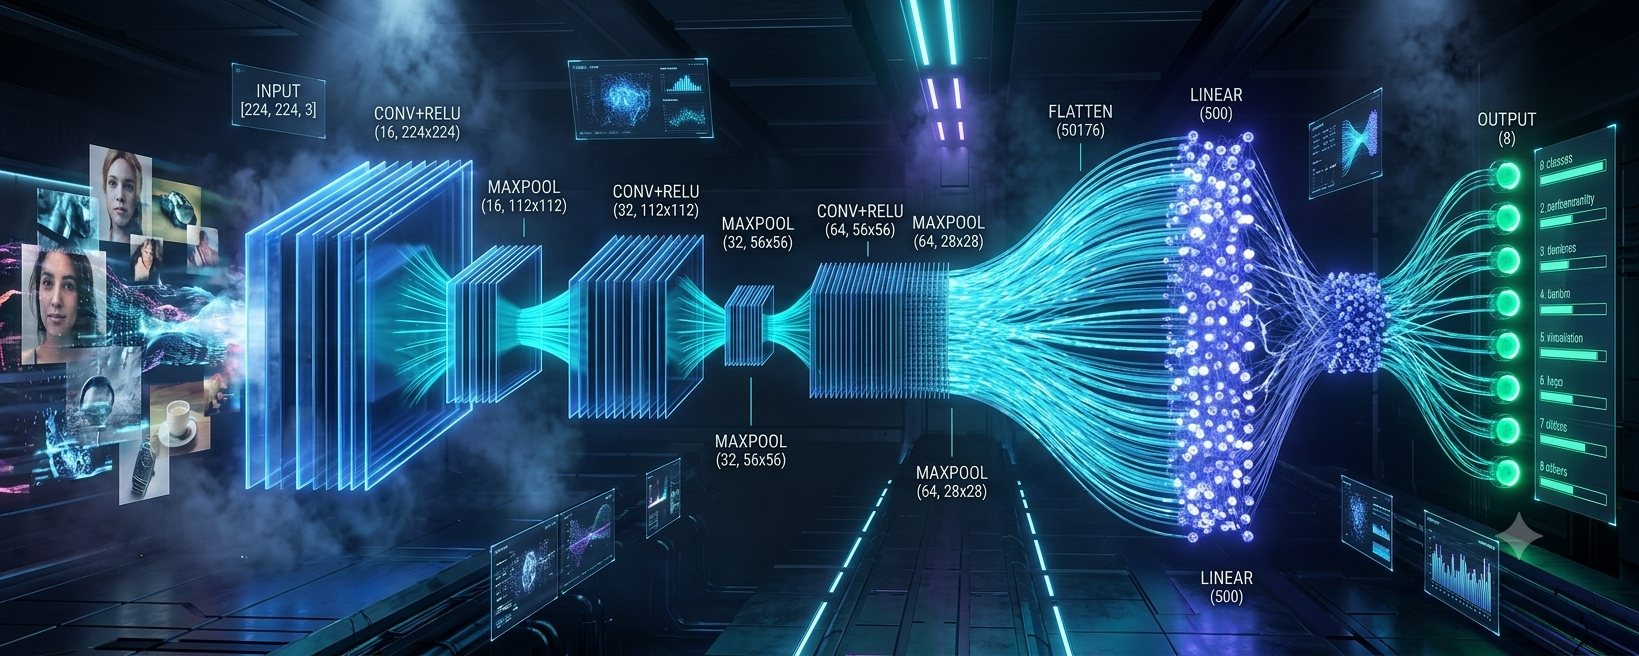

In [26]:
model = torch.nn.Sequential()

conv1 = torch.nn.Conv2d(in_channels=3, out_channels=16, kernel_size=(3, 3), padding=1)
max_pool1 = torch.nn.MaxPool2d(kernel_size=(2, 2), stride=2)
model.append(conv1)
model.append(torch.nn.ReLU())
model.append(max_pool1)

conv2 = torch.nn.Conv2d(in_channels=16, out_channels=32, kernel_size=(3, 3), padding=1)
max_pool2 = torch.nn.MaxPool2d(kernel_size=(2, 2), stride=2)
model.append(conv2)
model.append(torch.nn.ReLU())
model.append(max_pool2)

conv3 = torch.nn.Conv2d(32, 64, 3, padding=1)
max_pool3 = torch.nn.MaxPool2d(2)
model.append(conv3)
model.append(torch.nn.ReLU())
model.append(max_pool3)

model.append(torch.nn.Flatten())
model.append(torch.nn.Dropout())

linear1 = torch.nn.Linear(in_features=50176, out_features=500)
model.append(linear1)
model.append(torch.nn.ReLU())
model.append(torch.nn.Dropout())

output_layer = torch.nn.Linear(500, 9)
model.append(output_layer)

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): ReLU()
  (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (9): Flatten(start_dim=1, end_dim=-1)
  (10): Dropout(p=0.5, inplace=False)
  (11): Linear(in_features=50176, out_features=500, bias=True)
  (12): ReLU()
  (13): Dropout(p=0.5, inplace=False)
  (14): Linear(in_features=500, out_features=9, bias=True)
)

In [27]:
height, width = 224, 224
summary(model, input_size=(batch_size, 3, height, width))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [32, 9]                   --
├─Conv2d: 1-1                            [32, 16, 224, 224]        448
├─ReLU: 1-2                              [32, 16, 224, 224]        --
├─MaxPool2d: 1-3                         [32, 16, 112, 112]        --
├─Conv2d: 1-4                            [32, 32, 112, 112]        4,640
├─ReLU: 1-5                              [32, 32, 112, 112]        --
├─MaxPool2d: 1-6                         [32, 32, 56, 56]          --
├─Conv2d: 1-7                            [32, 64, 56, 56]          18,496
├─ReLU: 1-8                              [32, 64, 56, 56]          --
├─MaxPool2d: 1-9                         [32, 64, 28, 28]          --
├─Flatten: 1-10                          [32, 50176]               --
├─Dropout: 1-11                          [32, 50176]               --
├─Linear: 1-12                           [32, 500]                 25,088,500

In [28]:
from training import predict, train

In [30]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model.to(device="cpu")

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): ReLU()
  (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (9): Flatten(start_dim=1, end_dim=-1)
  (10): Dropout(p=0.5, inplace=False)
  (11): Linear(in_features=50176, out_features=500, bias=True)
  (12): ReLU()
  (13): Dropout(p=0.5, inplace=False)
  (14): Linear(in_features=500, out_features=9, bias=True)
)

In [31]:
train(model,optimizer,loss_fn,train_loader,val_loader,epochs=5,device="cpu")

Training:   0%|          | 0/155 [00:00<?, ?it/s]

Scoring:   0%|          | 0/39 [00:00<?, ?it/s]

Epoch: 1, Training Loss: 1.55, Validation Loss: 1.40, Validation accuracy = 0.51


Training:   0%|          | 0/155 [00:00<?, ?it/s]

Scoring:   0%|          | 0/39 [00:00<?, ?it/s]

...

Scoring:   0%|          | 0/39 [00:00<?, ?it/s]

Epoch: 4, Training Loss: 1.10, Validation Loss: 1.26, Validation accuracy = 0.55


Training:   0%|          | 0/155 [00:00<?, ?it/s]

Scoring:   0%|          | 0/39 [00:00<?, ?it/s]

Epoch: 5, Training Loss: 0.93, Validation Loss: 1.24, Validation accuracy = 0.58


In [35]:
device="cpu"
probabilities = predict(model, val_loader, device=device)
predictions = torch.argmax(probabilities,dim=1)

Predicting:   0%|          | 0/39 [00:00<?, ?it/s]

In [36]:
targets = []

for _, labels in tqdm(val_loader):
    targets.extend(labels.tolist())

  0%|          | 0/39 [00:00<?, ?it/s]

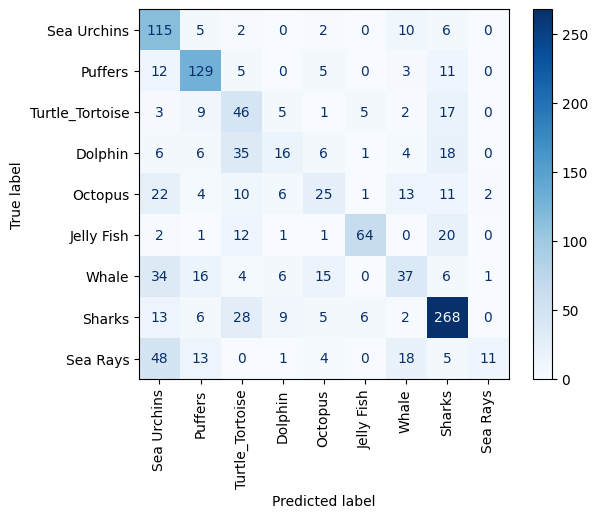

In [37]:
cm = confusion_matrix(targets, predictions.cpu())

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

disp.plot(cmap=plt.cm.Blues, xticks_rotation="vertical")
plt.show();

In [38]:
torch.save(model.state_dict(), "Marine_deepnet.pth")